# 05 — Model Explainability

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

shap.initjs()

## 1. Load Data & Model

In [3]:
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
try:
    best_model = joblib.load('../azure_package/churn-model/churn_model.pkl')
    print('Loaded model from artifact.')
except FileNotFoundError:
    print('Artifact not found — re-training with known best params.')
    best_model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    )
    best_model.fit(X_train, y_train)

Loaded model from artifact.


## 2. SHAP Explainer

In [5]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print('SHAP values shape:', shap_values.shape)

SHAP values shape: (1407, 23)


## 3. Global Explainability — Summary Plot

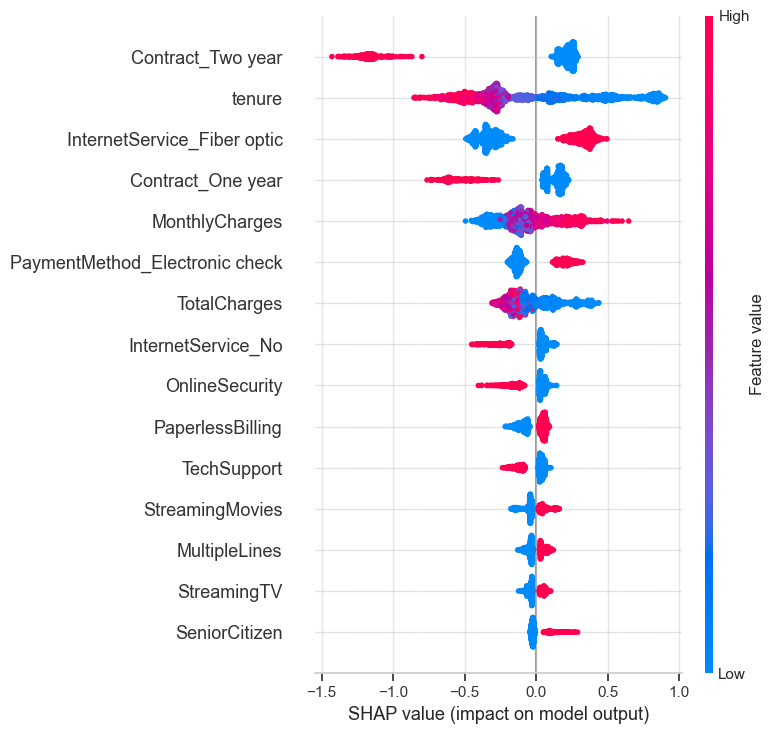

In [6]:
# Bee-swarm: each dot = one customer, colour = feature value, x-axis = SHAP impact
shap.summary_plot(shap_values, X_test, plot_type='dot', max_display=15)

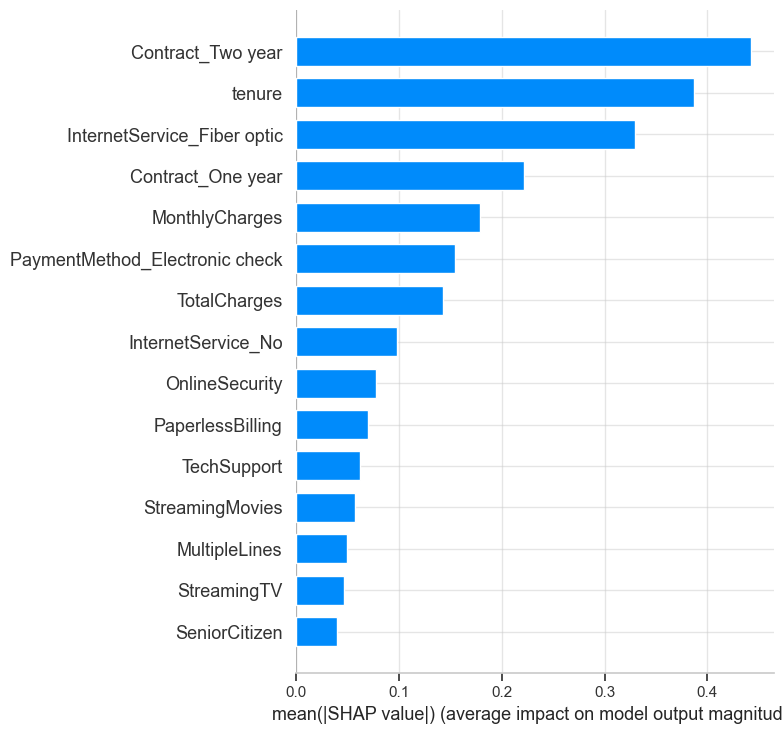

In [7]:
# Bar chart: mean absolute SHAP value per feature (cleaner for reports)
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

## 4. SHAP Dependence Plots — Top Features

In [8]:
# Mean SHAP magnitude per feature
mean_shap = np.abs(shap_values).mean(axis=0)
top_features = X_test.columns[np.argsort(mean_shap)[::-1]][:5]

print('Top 5 features by mean |SHAP|:')
for i, f in enumerate(top_features):
    print(f'  {i+1}. {f}  ({mean_shap[list(X_test.columns).index(f)]:.4f})')

Top 5 features by mean |SHAP|:
  1. Contract_Two year  (0.4425)
  2. tenure  (0.3866)
  3. InternetService_Fiber optic  (0.3294)
  4. Contract_One year  (0.2218)
  5. MonthlyCharges  (0.1789)


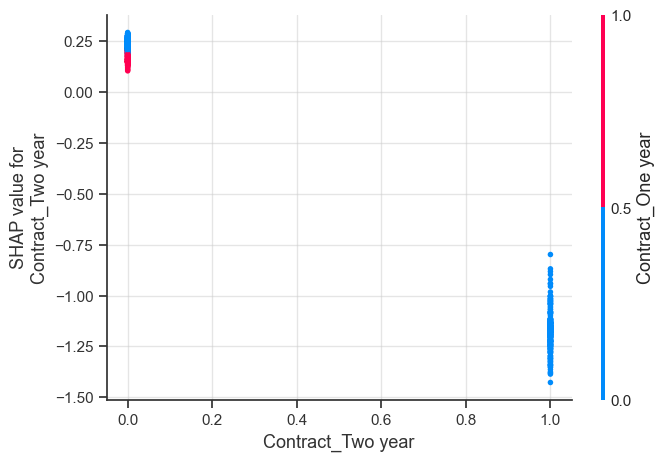

In [9]:
# Dependence plot for the top feature: shows how its value drives the SHAP contribution
shap.dependence_plot(top_features[0], shap_values, X_test)

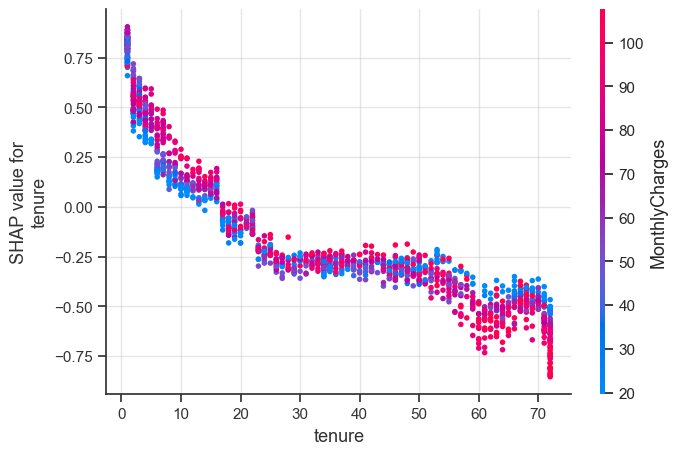

In [10]:
shap.dependence_plot(top_features[1], shap_values, X_test)

## 5. Local Explainability — Single Customer Waterfall

Explaining customer at test index 1
True label: 0 | Predicted: 1


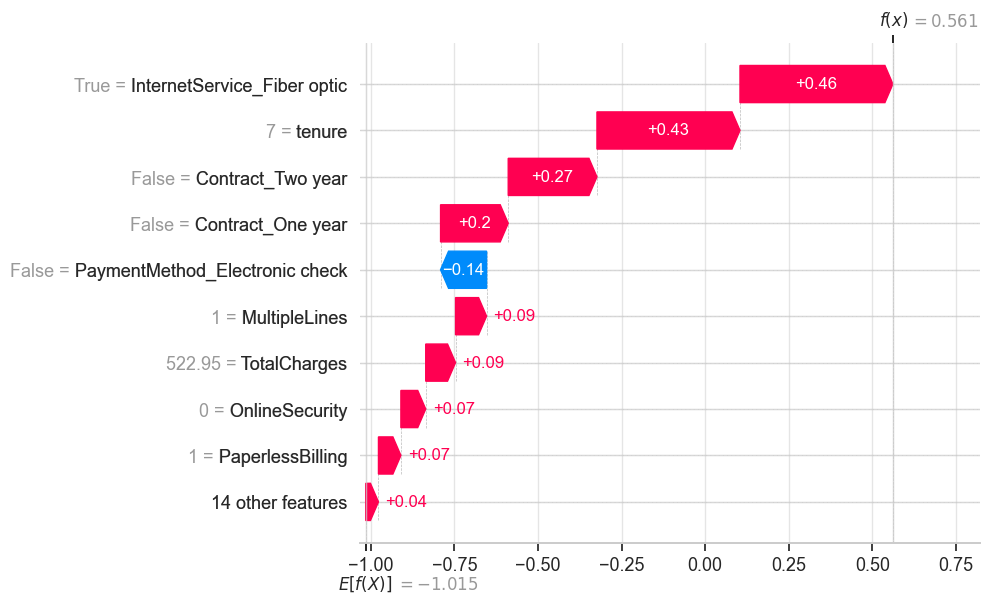

In [12]:
# Pick a customer who was predicted to churn
y_pred  = best_model.predict(X_test)
churn_idx = np.where(y_pred == 1)[0][0]

print(f'Explaining customer at test index {churn_idx}')
print(f'True label: {y_test.iloc[churn_idx]} | Predicted: {y_pred[churn_idx]}')

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[churn_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[churn_idx].values,
        feature_names=list(X_test.columns)
    )
)

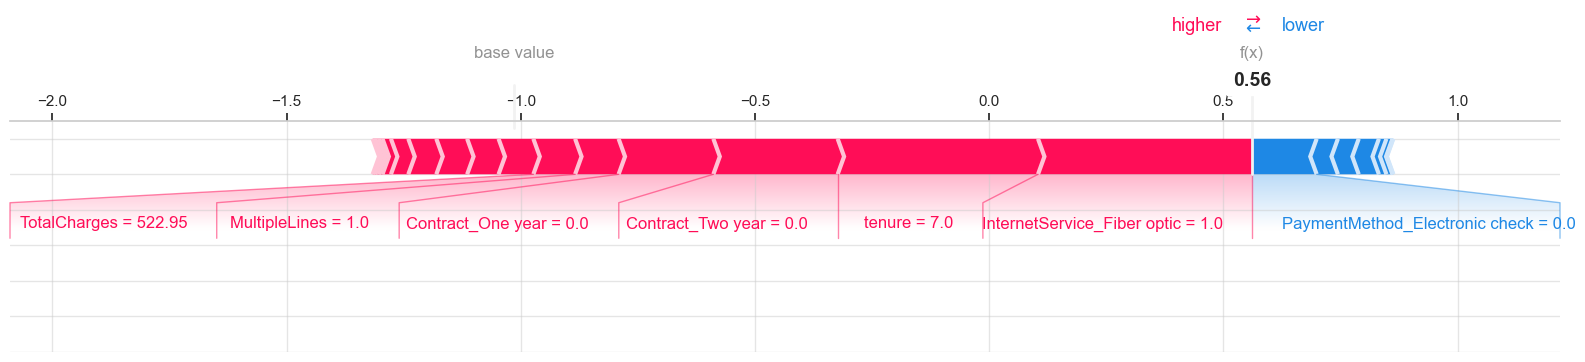

<Figure size 640x480 with 0 Axes>

In [13]:
# Force plot — alternative local view (interactive in Jupyter)
shap.force_plot(
    explainer.expected_value,
    shap_values[churn_idx],
    X_test.iloc[churn_idx],
    matplotlib=True
)
plt.tight_layout()
plt.show()

## 6. Mean SHAP per Feature — Custom Bar Chart

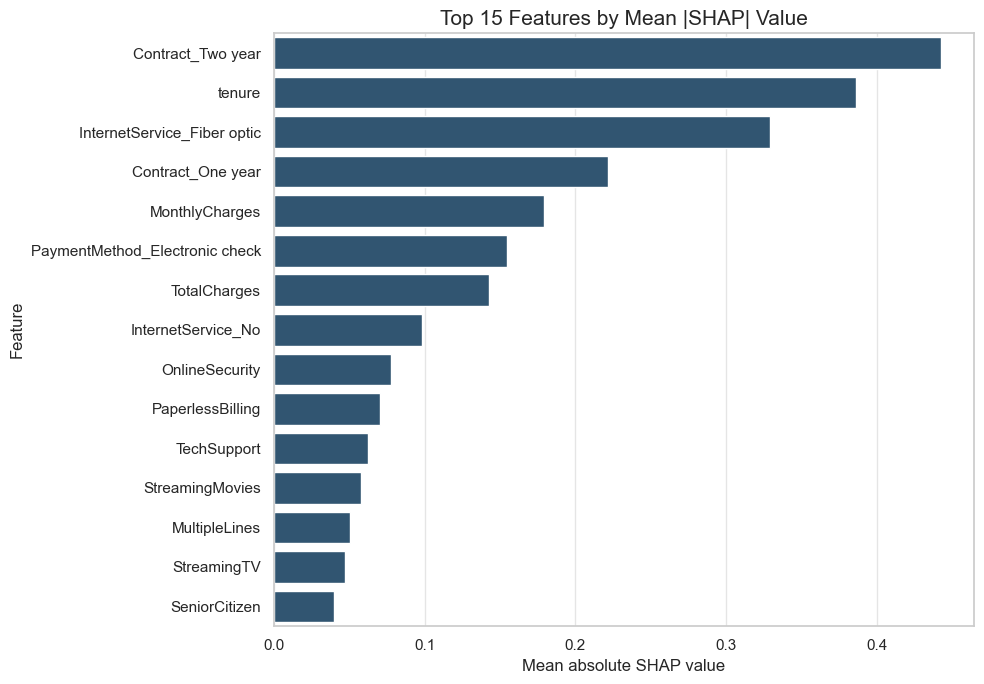


Top 10 churn drivers:
  Contract_Two year                        0.4425
  tenure                                   0.3866
  InternetService_Fiber optic              0.3294
  Contract_One year                        0.2218
  MonthlyCharges                           0.1789
  PaymentMethod_Electronic check           0.1548
  TotalCharges                             0.1429
  InternetService_No                       0.0982
  OnlineSecurity                           0.0774
  PaperlessBilling                         0.0702


In [14]:
shap_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=shap_df, x='Mean |SHAP|', y='Feature', color='#26577C')
plt.title('Top 15 Features by Mean |SHAP| Value', fontsize=15)
plt.xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.show()

print('\nTop 10 churn drivers:')
for _, row in shap_df.head(10).iterrows():
    print(f"  {row['Feature']:<40} {row['Mean |SHAP|']:.4f}")